# SGI-5.9 — What does fame buy?

**Marvel Superstars**, week 5 (exercise 5.9, "Go nuts with your LLM"). This week the Marvel network gets its text:
the full Wikipedia article for each of the 303 characters.

**The question.** A character other pages link to a lot is famous *inside* the network. Does fame buy a longer
Wikipedia page, and if it does, what are the extra words about: the story world (plot, powers, alternate versions),
or the comic as a real-world object (who drew it, how it sold, the film)?

Every number in the post comes from this notebook through `stats.json`. Each section ends with a **Result** written
after reading the output.

*Revised 2026-10-05 after Anas's review: index bug in the no-plot-heading set fixed, "plot share" renamed to
"in-universe share" (it is what the classifier measures), out-of-fold scores for the template pages, an optional
reading sheet for a hand check (not done; the post says so), and wording that treats length as the path from fame to content, not a rival to it.*

In [1]:
import collections
import json
import re
import urllib.parse
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import spacy
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GroupKFold
from sklearn.naive_bayes import MultinomialNB

DATA1, DATA5 = Path("../../Data/Week1"), Path("../../Data/Week5")
FIGDIR = Path("../../Figures/Week5")      # written straight to where the post reads them
FIGDIR.mkdir(parents=True, exist_ok=True)
POST = Path("../../posts/week5/index.html")
UM, INK, PALE, MID = "#2438E8", "#111316", "#B4B9C0", "#5B6068"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
STATS = {}

## 1. Load: the network from week 1, the text from week 5

The node file is the roster (303 characters, 17 with no link at all), the edges are A → B where A's article text
links to B's. The pages come as one zip; the filenames are URL-encoded node ids, so they are unquoted to join (the
course data page's snippet). **Fame** here is **in-degree**: how many of the other 302 articles link to you.

In [2]:
nodes = pd.read_csv(DATA1 / "week1_nodes.tsv", sep="\t", comment="#", quoting=3).set_index("node_id")
edges = pd.read_csv(DATA1 / "week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
G = nx.DiGraph()
G.add_nodes_from(nodes.index)
G.add_edges_from(edges.itertuples(index=False))
with zipfile.ZipFile(DATA5 / "marvel_pages.zip") as z:
    pages = {urllib.parse.unquote(n.split("/")[-1][:-4]): z.read(n).decode("utf-8")
             for n in z.namelist() if n.endswith(".txt") and "README" not in n}
assert set(pages) == set(nodes.index) and G.number_of_nodes() == 303 and G.number_of_edges() == 1784

name = nodes.name
df = pd.DataFrame({"kin": dict(G.in_degree()), "kout": dict(G.out_degree())})
df["chars"] = pd.Series({k: len(t) for k, t in pages.items()})
print(df.describe().round(1))

         kin   kout    chars
count  303.0  303.0    303.0
mean     5.9    5.9  14678.8
std     10.0    5.1  15963.8
min      0.0    0.0   1244.0
25%      1.0    2.0   4482.5
50%      3.0    4.0   7642.0
75%      7.0    8.5  18439.5
max    106.0   28.0  87256.0


## 2. Does fame buy words?

**Tokenization choice.** spaCy's English tokenizer (rules only, no model needed), keeping case, dropping punctuation
and whitespace tokens. A page's **length** is its number of remaining tokens. Preprocessing is part of the model, so
§6 repeats the measurement with a plain `str.split()`.

**Measures.** The main number is the Spearman rank correlation of length with in-degree: it uses only the order of
the pages, so it needs no choice of axes. To say *how much* longer, we also draw a least-squares straight line through
$\log_{10}(\text{tokens})$ against $\log_{10}(k_{in}+1)$. This is a regression of one variable on another, not a
fit of a power-law *distribution* (week 2 explains why least squares on log-log axes is the wrong way to fit those).
The $+1$ is what week 1 does to show degree 0 on a log axis; it keeps the 58 pages nobody links to. Dropping them
instead changes the slope (printed below).

In [3]:
nlp = spacy.load("en_core_web_sm")
tokens = {k: [t.text for t in nlp.tokenizer(v) if not (t.is_punct or t.is_space)] for k, v in pages.items()}
df["tokens"] = pd.Series({k: len(v) for k, v in tokens.items()})


def by_kin(d):
    """most-linked first; ties broken by tokens, then by node id, so every machine gives the same order"""
    return d.sort_index().sort_values(["kin", "tokens"], ascending=False, kind="stable")


types = {w for v in tokens.values() for w in v}

rho_in = spearmanr(df.kin, df.tokens).statistic
rho_out = spearmanr(df.kout, df.tokens).statistic
x, y = np.log10(df.kin + 1), np.log10(df.tokens)
slope, icpt = np.polyfit(x, y, 1)
df["resid"] = y - (icpt + slope * x)
pos = df.kin > 0
slope_pos = np.polyfit(np.log10(df.kin[pos]), y[pos], 1)[0]
print(f"{df.tokens.sum():,} tokens, {len(types):,} types; Spearman tokens~k_in {rho_in:.2f}, tokens~k_out {rho_out:.2f}")
print(f"log-log slope {slope:.2f} (without the {(~pos).sum()} unlinked pages: {slope_pos:.2f})")
print(f"median length: k_in 0 {df.tokens[df.kin == 0].median():.0f}, k_in 0-1 {df.tokens[df.kin <= 1].median():.0f}, k_in >= 10 {df.tokens[df.kin >= 10].median():.0f}")

STATS["corpus"] = dict(pages=303, tokens=int(df.tokens.sum()), types=len(types), chars=int(df.chars.sum()),
                       min_tokens=int(df.tokens.min()), max_tokens=int(df.tokens.max()), median_tokens=int(df.tokens.median()),
                       longest=name[df.tokens.idxmax()], shortest=name[df.tokens.idxmin()])
STATS["fame"] = dict(rho_in=round(rho_in, 2), rho_out=round(rho_out, 2), slope=round(slope, 2), slope_pos=round(slope_pos, 2),
                     intercept=round(icpt, 3), median_low=int(df.tokens[df.kin <= 1].median()),
                     median_high=int(df.tokens[df.kin >= 10].median()), n_unlinked=int((df.kin == 0).sum()),
                     median_unlinked=round(float(df.tokens[df.kin == 0].median())))

744,495 tokens, 30,856 types; Spearman tokens~k_in 0.75, tokens~k_out 0.78
log-log slope 0.73 (without the 58 unlinked pages: 0.66)
median length: k_in 0 652, k_in 0-1 722, k_in >= 10 5971


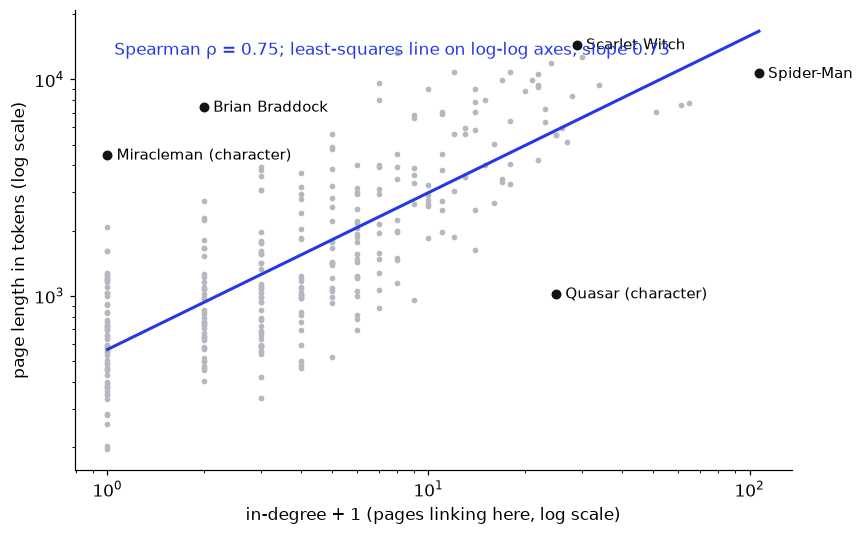

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.kin + 1, df.tokens, s=14, color=PALE, linewidths=0)
xs = np.logspace(0, np.log10(df.kin.max() + 1), 50)
ax.plot(xs, 10 ** icpt * xs ** slope, color=UM, lw=2)
for v in ["Spider-Man", "Scarlet_Witch", "Miracleman_(character)", "Brian_Braddock", "Quasar_(character)"]:
    ax.scatter([df.kin[v] + 1], [df.tokens[v]], s=30, color=INK, zorder=3)
    ax.annotate(name[v], (df.kin[v] + 1, df.tokens[v]), xytext=(6, -3), textcoords="offset points", fontsize=10)
ax.set(xscale="log", yscale="log", xlabel="in-degree + 1 (pages linking here, log scale)", ylabel="page length in tokens (log scale)")
ax.text(1.05, 13000, f"Spearman ρ = {rho_in:.2f}; least-squares line on log-log axes, slope {slope:.2f}", color=UM, fontsize=11)
fig.tight_layout(); fig.savefig(FIGDIR / "fig1_fame_length.png", dpi=150); plt.show()

**Result.** Fame buys words: Spearman $\rho = 0.75$. Less than one-for-one, though: the line's slope says ten times the
in-links goes with about $10^{0.73} \approx 5$ times the words. Out-degree correlates even more strongly with length,
plausibly in part because a longer article has more room to link out (we did not test this). In-degree is the
measure the page cannot write for itself.

## 3. What are the extra words about? Asking the headings

Wikipedia character pages share a template: *Publication history* (the real-world comic), *Fictional character
biography* (the plot), *Powers and abilities*, *Other versions*, *In other media*, *Reception*. In the plain text a
heading is a line after two blank lines. Sub-headings (`1970s`, `Excalibur`) inherit the last top-level heading
they sit under; we map the top-level names (and their common variants) to eight kinds.

**Fame groups.** In-degree 0–1, 2–3, 4–9 and 10+: 99, 71, 80 and 53 pages. Equal-count quartiles would cut through
tied degrees arbitrarily; these cuts sit between degrees.

In [5]:
KIND = {"Publication history": "publication", "Concept and creation": "publication", "Conception and creation": "publication",
        "Creation": "publication", "Development": "publication", "Creation and development": "publication", "Artistic conception": "publication",
        "Fictional character biography": "plot", "Fictional character biographies": "plot", "Biography": "plot",
        "Powers and abilities": "powers", "Powers, skills, and equipment": "powers",
        "Other versions": "versions", "Alternate versions": "versions", "In other media": "media",
        "Reception": "reception", "Literary reception": "reception", "Cultural impact and legacy": "reception",
        "Accolades": "reception", "Reception and legacy": "reception",
        "References": "back", "External links": "back", "Notes": "back", "See also": "back",
        "Collected editions": "back", "Bibliography": "back", "Further reading": "back"}
KINDS = ["lead", "publication", "plot", "powers", "versions", "media", "reception", "back"]
HEAD = re.compile(r"\n\n\n([^\n]{1,80})(?=\n)")     # lookahead: back-to-back headings are both found


def sections(text):
    # (kind, heading, body) for every chunk of a page; the lead is everything before the first heading
    parts = HEAD.split(text)
    out, kind = [("lead", "", parts[0])], "lead"
    for h, body in zip(parts[1::2], parts[2::2]):
        kind = KIND.get(h.strip(), kind)
        out.append((kind, h.strip(), body))
    return out


ntok = lambda s: sum(1 for t in nlp.tokenizer(s) if not (t.is_punct or t.is_space))
sec = pd.DataFrame(0, index=list(pages), columns=KINDS)
for k, t in pages.items():
    for kd, _, body in sections(t):
        sec.loc[k, kd] += ntok(body)
BINS, LABELS = [-0.5, 1.5, 3.5, 9.5, 1e9], ["0–1", "2–3", "4–9", "10+"]
df["fame"] = pd.cut(df.kin, BINS, labels=LABELS)
pooled = sec.groupby(df.fame, observed=True).sum()
head_share = pooled.div(pooled.sum(axis=1), axis=0)
# Select by label from sec itself: sec (zip order) and df (graph order) list the pages in different orders, and a
# boolean Series from one frame used on the other's .index is applied by position, not by label.
no_plot = sec.index[sec["plot"] == 0]
assert set(no_plot) == {k for k in sec.index if sec.at[k, "plot"] == 0}          # label by label, not by position
# the same heading share per page, to compare like with like against the per-page medians of §5
head_page_median = (sec["plot"] / sec.sum(axis=1)).groupby(df.fame, observed=True).median()
print(head_share.round(3))
print("per-page median of the plot-heading share:", head_page_median.round(3).to_dict())
print(f"{len(no_plot)} pages have no plot heading; their median in-degree is {df.kin[no_plot].median():.1f} (all pages: {df.kin.median():.0f})")
print(by_kin(df.loc[no_plot]).head(10)[["kin", "tokens"]])

STATS["headings"] = dict(bins=LABELS, sizes=[int(n) for n in df.fame.value_counts().reindex(LABELS)], kinds=KINDS,
                         share={b: [round(float(v), 3) for v in head_share.loc[b]] for b in LABELS},
                         page_median=[round(float(head_page_median[b]), 3) for b in LABELS],
                         n_no_plot=len(no_plot), no_plot_median_kin=float(df.kin[no_plot].median()),
                         no_plot_top=[name[v] for v in by_kin(df.loc[no_plot]).index[:6]])

       lead  publication   plot  powers  versions  media  reception   back
fame                                                                      
0–1   0.086        0.186  0.477   0.091     0.047  0.048      0.040  0.025
2–3   0.075        0.157  0.469   0.125     0.042  0.064      0.051  0.017
4–9   0.050        0.154  0.432   0.134     0.075  0.070      0.067  0.018
10+   0.045        0.222  0.315   0.143     0.069  0.099      0.094  0.013
per-page median of the plot-heading share: {'0–1': 0.568, '2–3': 0.495, '4–9': 0.445, '10+': 0.361}
22 pages have no plot heading; their median in-degree is 3.5 (all pages: 3)
                                kin  tokens
Deadpool                         33    9384
Cable_(character)                21    4234
Venom_(character)                17   10837
Ghost_Rider                      13    7066
Ms._Marvel                       11    1875
Spider-Woman                     10    2485
Bucky_(Marvel_Comics)             9    2911
Captain_Marvel_(Marvel

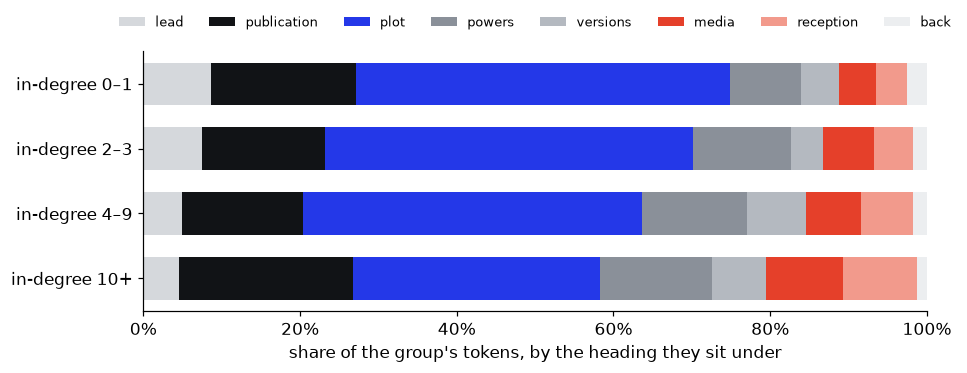

In [6]:
SEC_COL = {"lead": "#D5D8DC", "publication": INK, "plot": UM, "powers": "#8A9099", "versions": PALE,
           "media": "#E5402A", "reception": "#F29A8C", "back": "#ECEEF0"}
fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(LABELS))
for kd in KINDS:
    v = head_share[kd].values
    ax.barh(range(len(LABELS)), v, left=left, color=SEC_COL[kd], label=kd, height=.65)
    left += v
ax.set_yticks(range(len(LABELS)), [f"in-degree {b}" for b in LABELS]); ax.invert_yaxis()
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(ncol=8, fontsize=8.5, loc="upper center", bbox_to_anchor=(.5, 1.18), frameon=False)
ax.set_xlabel("share of the group's tokens, by the heading they sit under")
fig.tight_layout(); fig.savefig(FIGDIR / "fig2_headings.png", dpi=150); plt.show()

**Result, provisionally.** By the headings, the most-linked pages are about a third plot (32%), against nearly half
(48%) for the least-linked. But a heading is an editor's filing decision, not a measurement of what a paragraph says.
Per page, the median plot-heading share falls from 57% to 36%. 22 pages have none of the plot headings we map
(Deadpool, Cable and Venom among them): some file plot under a variant
we do not map (*Character biography* on Spider-Man Noir), some tell it under *Powers*, *Other versions* or the lead.
So we measure the paragraphs themselves.

## 4. Reading paragraphs instead of headings

We let the text decide. **The document is the unit we choose, and here it is the paragraph**, not the page. On the
239 pages that have **both** a *Publication history* and a *Fictional character biography* heading, every paragraph of
20+ words under those two headings is a labelled document: real-world or in-universe.

**Bag of Words.** Each paragraph becomes a row of word counts (CountVectorizer, lowercased, stopwords kept on purpose:
the story is told in the present tense, *tells*, *escapes*, the publishing history in the past, *was*, *appeared*).
The rows form a document-term matrix; BoW throws away word order, but the tense signal survives in the counts.

**Word score.** For each word, compare its **relative frequency** (count divided by the class total) in in-universe
paragraphs with its relative frequency in real-world paragraphs, adding one to every count so a word unseen in one
class does not divide by zero. A paragraph's score is the sum of its words' log-ratios plus a constant for the
classes' sizes. That is multinomial naive Bayes with add-one smoothing (Jurafsky & Martin, Appendix B; scikit-learn
`MultinomialNB` with $\alpha = 1$).

**Why "in-universe" and not "plot".** The classifier only knows two classes, so it must put every paragraph — powers,
alternate versions, adaptations — into one of them. §5 shows it puts *Powers and abilities* and *Other versions*
almost entirely on the story side. What it measures is in-universe versus real-world writing, so that is its name.

**Validation**, two kinds:
1. **Held-out pages.** 5-fold cross-validation grouped by page, so no page is in both training and test. The scores
   used later for the 239 template pages are these out-of-fold scores: each page is scored by the model that did not
   see it.
2. **Out-of-template pages.** The held-out pages still have the template. The 64 pages without both headings are
   exactly the ones we need to measure, but they have no labels. We did not hand-label them, so the post reports no
   accuracy there. The cell below still draws 24 random paragraphs and writes them to an optional reading sheet, in
   case someone wants to check later.

In [7]:
rows = []
for k, t in pages.items():
    for kd, _, body in sections(t):
        for para in body.split("\n"):
            if len(para.split()) >= 20:
                rows.append((k, kd, para, len(para.split())))
PAR = pd.DataFrame(rows, columns=["page", "kind", "text", "words"])
heads = {k: {h for _, h, _ in sections(t)} for k, t in pages.items()}
both = sorted(k for k in pages if {"Publication history", "Fictional character biography"} <= heads[k])
T = PAR[PAR.page.isin(both) & PAR.kind.isin(["publication", "plot"])].reset_index(drop=True)
yT = (T.kind == "plot").values          # True = in-universe (the plot heading), False = real-world

# Page-grouped 5-fold CV. Each fold's model also scores every paragraph (any heading) of its held-out pages, so the
# template pages get out-of-fold scores; the 64 off-template pages are scored by the model trained on all 239.
acc, PAR["p_inu"] = [], np.nan
for tr, te in GroupKFold(n_splits=5).split(T.text, yT, groups=T.page):
    v = CountVectorizer(lowercase=True)
    m = MultinomialNB().fit(v.fit_transform(T.text.iloc[tr]), yT[tr])
    acc.append((m.predict(v.transform(T.text.iloc[te])) == yT[te]).mean())
    held = PAR.page.isin(set(T.page.iloc[te]))
    PAR.loc[held, "p_inu"] = m.predict_proba(v.transform(PAR.text[held]))[:, 1]
vec = CountVectorizer(lowercase=True)
X = vec.fit_transform(T.text)                                   # the document-term matrix: one row per paragraph
clf = MultinomialNB().fit(X, yT)
off = PAR.p_inu.isna()
assert set(PAR.page[off]) == set(pages) - set(T.page)
PAR.loc[off, "p_inu"] = clf.predict_proba(vec.transform(PAR.text[off]))[:, 1]
PAR["is_inu"] = PAR.p_inu > 0.5
in_sample = (clf.predict(X) == yT).mean()

# Word score: log of (relative frequency in in-universe paragraphs) / (relative frequency in real-world paragraphs),
# one count added to every word. Sorted with an explicit tie-break, since many words tie exactly.
score = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
log_prior = float(clf.class_log_prior_[1] - clf.class_log_prior_[0])
vocab = vec.get_feature_names_out()
word_count = np.asarray(X.sum(axis=0)).ravel()
common = sorted((i for i in range(len(vocab)) if word_count[i] >= 30), key=lambda i: (score[i], vocab[i]))   # 30+ uses
real_words = [vocab[i] for i in common[:15]]
inu_words = [vocab[i] for i in common[::-1][:15]]

# raw counts against relative frequencies, for a few words
cnt, N = clf.feature_count_, clf.feature_count_.sum(axis=1)       # row 0 real-world, row 1 in-universe
col = {w: j for j, w in enumerate(vocab)}
REL = [[w, int(cnt[1, col[w]]), int(cnt[0, col[w]]), round(1e4 * cnt[1, col[w]] / N[1], 1), round(1e4 * cnt[0, col[w]] / N[0], 1),
        round(float(score[col[w]]), 2)] for w in ["escapes", "tells", "is", "was", "reprinted", "penciller"]]
zeros = 1 - X.nnz / (X.shape[0] * X.shape[1])

print(f"{len(both)} template pages, {len(T):,} labelled paragraphs ({yT.mean():.0%} in-universe)")
print(f"document-term matrix {X.shape[0]:,} paragraphs x {X.shape[1]:,} terms, {zeros:.2%} of cells zero; "
      f"total tokens: in-universe {int(N[1]):,}, real-world {int(N[0]):,}")
print(f"page-grouped 5-fold accuracy {np.mean(acc):.3f} (range over folds {min(acc):.3f}-{max(acc):.3f}); "
      f"in-sample {in_sample:.3f}; always-in-universe baseline {yT.mean():.3f}; log prior ratio {log_prior:.3f} nats")
print("real-world words:", real_words)
print("in-universe words:", inu_words)
print(pd.DataFrame(REL, columns=["word", "n in-universe", "n real", "per 10k in-universe", "per 10k real", "score"]).to_string(index=False))

239 template pages, 3,786 labelled paragraphs (69% in-universe)
document-term matrix 3,786 paragraphs x 18,984 terms, 99.66% of cells zero; total tokens: in-universe 249,913, real-world 105,266
page-grouped 5-fold accuracy 0.943 (range over folds 0.912-0.960); in-sample 0.965; always-in-universe baseline 0.691; log prior ratio 0.803 nats
real-world words: ['august', 'february', 'ditko', 'december', 'stan', 'sept', 'romita', 'wolfman', '1987', 'penciller', 'penciler', 'premiere', 'reprinted', 'kirby', 'september']
in-universe words: ['ship', 'escapes', 'freed', 'asgard', 'facility', 'balder', 'horde', 'secretly', 'attacking', 'teddy', 'activities', 'tells', 'breaks', 'attack', 'portal']
     word  n in-universe  n real  per 10k in-universe  per 10k real  score
  escapes             67       0                  2.7           0.0   3.45
    tells            107       2                  4.3           0.2   2.81
       is           3374     467                135.0          44.4   1.20
     

In [8]:
# The out-of-template check. 24 random paragraphs from the 22 pages with no plot heading (back matter excluded).
# A group member reads each one in full in reading_sheet.md and writes what it does: tell the story world ("inu")
# or describe the real world ("real"). The labels go in HUMAN, keyed by the paragraph's PAR row number.
# Until READ_BY is set and all 24 are labelled, the agreement is not computed and the post says the check is pending.
CHECK = PAR[PAR.page.isin(no_plot) & (PAR.kind != "back")].sample(24, random_state=7)
READ_BY = None          # e.g. "Martin Møllenhus, 2026-10-07"
HUMAN = {}              # e.g. {6531: "real", 6594: "inu", ...}

# First-pass labels by Claude Code for the paragraphs that were also in the earlier (buggy) sample; shown in the sheet
# after the paragraph, for comparison only. They do not count as a reading.
CLAUDE_FIRST = {6531: "real", 6594: "inu", 7554: "inu", 7561: "real", 2595: "real", 7601: "real", 7543: "inu", 2201: "real",
                1605: "inu", 2575: "real", 4279: "inu", 1146: "real", 7498: "real", 6829: "inu", 6584: "inu", 7511: "real",
                1557: "real", 1700: "inu", 6606: "real", 2590: "real", 2572: "real", 7100: "real", 7549: "real", 7493: "inu"}
assert all(v in ("inu", "real") for v in HUMAN.values()) and set(HUMAN) <= set(CHECK.index)
CHECK = CHECK.assign(model=np.where(CHECK.is_inu, "inu", "real"), reading=[HUMAN.get(i) for i in CHECK.index])
done = READ_BY is not None and len(HUMAN) == 24
agree = int((CHECK.reading == CHECK.model).sum()) if done else None
with pd.option_context("display.max_colwidth", 100):
    print(CHECK.assign(text=CHECK.text.str[:100])[["page", "kind", "model", "reading", "text"]].to_string())
print(f"agree on {agree} of 24, read by {READ_BY}" if done else f"reading pending: {len(HUMAN)} of 24 labelled, READ_BY = {READ_BY}")
print(f"{len(set(CHECK.index) & set(CLAUDE_FIRST))} of the 24 were also in the earlier sample")
STATS["classifier"] = dict(template_pages=len(both), paragraphs=len(T), inu_base=round(float(yT.mean()), 3),
                           cv_acc=round(float(np.mean(acc)), 3), cv_min=round(float(min(acc)), 3), cv_max=round(float(max(acc)), 3),
                           in_sample=round(float(in_sample), 3), log_prior=round(log_prior, 2),
                           dtm=[int(X.shape[0]), int(X.shape[1]), round(float(zeros), 4)], class_tokens=[int(N[1]), int(N[0])],
                           rel_freq=REL, real_words=real_words, inu_words=inu_words,
                           check_n=24, check_read_by=READ_BY, check_agree=agree,
                           check_misses=[[name[r.page], r.kind, r.model, r.reading] for r in CHECK[CHECK.reading != CHECK.model].itertuples()] if done else None)

                                page         kind model reading                                                                                                  text
6573                    Spider-Woman         lead  real    None  Spider-Woman is the code name of several fictional characters in comic books published by Marvel Com
6398                     Spider-Girl  publication   inu    None  The second volume of Spider-Boy introduces a new incarnation of Spider-Girl who is the supervillain 
6392                     Spider-Girl  publication  real    None  Spider-Boy vol. 2 #12 (October 2024) introduced the supervillain Funhouse (Makawalu "Maka" Akana), t
1750                      Devil_Hulk         lead  real    None  The Devil Hulk, also known as the Immortal Hulk, is a fictional alternate-personality character appe
1149               Cable_(character)  publication   inu    None  Cable is seen in the year 2087 dealing with some unidentified issue related to Stryfe, in the afterm
4284

**Result.** The classifier is right on 94% of paragraphs from pages it never saw (range over the 5 folds 91–96%),
against 69% for always guessing in-universe. Scored on its own training paragraphs it gets 96.5%, which is why the
template pages use out-of-fold scores. Its strongest words are what you would hope: months, years and creators' names
(*ditko*, *romita*, *penciller*) for the real world; places and verbs of action (*escapes*, *freed*, *asgard*,
*facility*) for the story world. The relative-frequency table shows why stopwords stay: *is* and *was* are not
informative alone, but their rates differ between the classes. Off the template there are no labels, and we did not
hand-check it, so we report no accuracy there.

## 5. Is it fame, or is it length?

A page's **in-universe share** is the share of its words (in paragraphs of 20+ words) that sit in paragraphs the
classifier puts on the story-world side. First, what that side contains, by the heading a paragraph sits under:
the classifier was trained only on *Fictional character biography* and *Publication history*, so this shows where
the rest of each page goes.

Famous pages are long, and a long page has room for reception, adaptations and a publication history. Length is
therefore a likely *path* from fame to content: fame → longer page → more real-world sections. To ask whether fame
does anything **beyond** that path, compare famous and obscure pages **of the same length**: split pages into length
terciles, and compute the Spearman correlation of in-universe share with in-degree after removing what length explains
from both ranks (a partial correlation). A near-zero partial correlation says fame adds nothing beyond length; it does
not say length replaces fame, because fame is what bought the length.

In [9]:
r = PAR.assign(iw=PAR.words * PAR.is_inu).groupby("kind")[["iw", "words"]].sum()
by_kind = (r.iw / r.words).reindex(KINDS)
fam = PAR.page.map(df.fame)
out = ~PAR.kind.isin(["plot", "publication"])
outside = PAR[out].groupby(fam[out], observed=True).words.sum() / PAR.groupby(fam, observed=True).words.sum()
print("share of paragraph words the classifier calls in-universe, by heading kind:", by_kind.round(3).to_dict())
print("share of paragraph words outside the two trained headings, by fame:", outside.round(3).to_dict())

g = PAR.assign(iw=PAR.words * PAR.is_inu).groupby("page")[["iw", "words"]].sum()
df["inu_share"] = g.iw / g.words
df["para_words"] = g.words
pooled_inu = PAR.assign(iw=PAR.words * PAR.is_inu).groupby(fam, observed=True)[["iw", "words"]].sum()
pooled_inu = pooled_inu.iw / pooled_inu.words
rho_share = spearmanr(df.kin, df.inu_share).statistic
rho_len = spearmanr(df.tokens, df.inu_share).statistic


def partial_spearman(a, b, control):
    ra, rb, rc = a.rank(), b.rank(), control.rank()
    res = lambda r: r - np.polyval(np.polyfit(rc, r, 1), rc)
    return float(np.corrcoef(res(ra), res(rb))[0, 1])


partial = partial_spearman(df.inu_share, df.kin, df.tokens)
df["length"] = pd.qcut(df.tokens, 3, labels=["short", "middle", "long"])
by_fame = df.groupby("fame", observed=True).inu_share.median()
table = df.groupby(["length", "fame"], observed=True).inu_share.agg(["median", "count"])
cuts = df.groupby("length", observed=True).tokens.agg(["min", "max"])
print("per-page median in-universe share:", by_fame.round(3).to_dict(), "| pooled:", pooled_inu.round(3).to_dict())
print(cuts); print(table.round(3))
print(f"Spearman in-universe share ~ k_in {rho_share:.2f}; ~ length {rho_len:.2f}; ~ k_in controlling for length {partial:.3f}")

STATS["inu_share"] = dict(by_kind={k: round(float(v), 3) for k, v in by_kind.items()},
                          outside_trained=[round(float(outside[b]), 3) for b in LABELS],
                          by_fame=[round(float(by_fame[b]), 3) for b in LABELS], pooled=[round(float(pooled_inu[b]), 3) for b in LABELS],
                          rho_kin=round(rho_share, 2), rho_len=round(rho_len, 2), partial=round(partial, 2),
                          tercile_cuts=[[int(cuts.loc[t, "min"]), int(cuts.loc[t, "max"])] for t in ["short", "middle", "long"]],
                          table={f"{t}|{b}": [round(float(r["median"]), 3), int(r["count"])] for (t, b), r in table.iterrows()})

share of paragraph words the classifier calls in-universe, by heading kind: {'lead': 0.229, 'publication': 0.177, 'plot': 0.96, 'powers': 0.931, 'versions': 0.845, 'media': 0.489, 'reception': 0.147, 'back': 0.012}
share of paragraph words outside the two trained headings, by fame: {'0–1': 0.308, '2–3': 0.343, '4–9': 0.385, '10+': 0.439}
per-page median in-universe share: {'0–1': 0.779, '2–3': 0.768, '4–9': 0.719, '10+': 0.652} | pooled: {'0–1': 0.695, '2–3': 0.721, '4–9': 0.708, '10+': 0.607}
         min    max
length             
short    195    969
middle   971   2179
long    2204  14469
             median  count
length fame               
short  0–1    0.815     66
       2–3    0.828     28
       4–9    0.719      7
middle 0–1    0.732     28
       2–3    0.765     33
       4–9    0.718     36
       10+    0.530      4
long   0–1    0.554      5
       2–3    0.703     10
       4–9    0.724     37
       10+    0.660     49
Spearman in-universe share ~ k_in -0.20; ~ length 

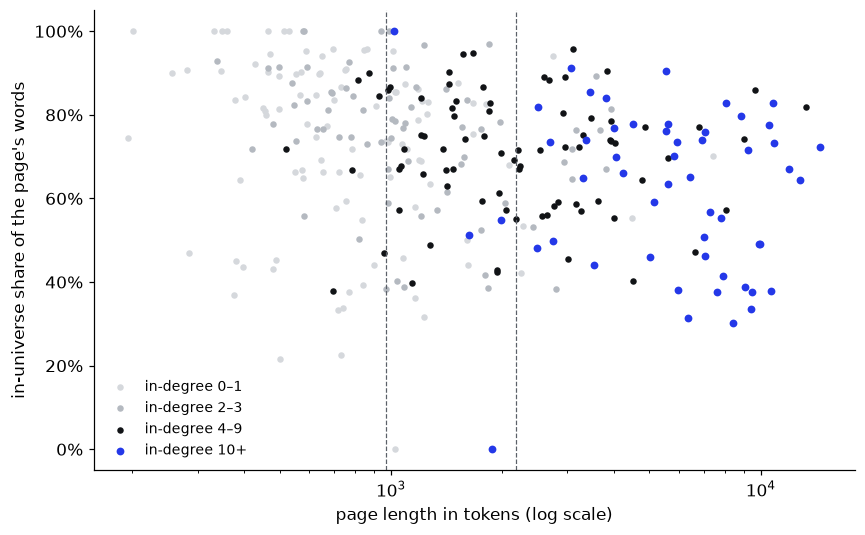

In [10]:
FAME_COL = dict(zip(LABELS, ["#D5D8DC", PALE, INK, UM]))
fig, ax = plt.subplots(figsize=(8, 5))
for b in LABELS:
    d = df[df.fame == b]
    ax.scatter(d.tokens, d.inu_share, s=18 if b != "10+" else 26, color=FAME_COL[b], label=f"in-degree {b}", linewidths=0, zorder=3 if b == "10+" else 2)
for c in cuts["max"].values[:2]:
    ax.axvline(c, color=MID, lw=.8, ls="--")
ax.set(xscale="log", xlabel="page length in tokens (log scale)", ylabel="in-universe share of the page's words")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(frameon=False, fontsize=9, loc="lower left")
fig.tight_layout(); fig.savefig(FIGDIR / "fig3_inuniverse_share.png", dpi=150); plt.show()

**Result.** The classifier's story-world side is wider than plot: it takes 96% of the words under plot headings, but
also 93% under *Powers and abilities*, 85% under *Other versions* and half under *In other media*, against
18% under *Publication history*. So the share measures in-universe versus real-world writing.

Famous pages spend less of themselves in-universe: the per-page median falls from 78% (in-degree 0–1) to 65% (10+),
Spearman $\rho = -0.20$. In-universe share also falls with length, whoever the character is ($\rho = -0.31$). Once
length is held fixed, the correlation with in-degree is $0.05$: no effect of fame beyond length. Among long pages the
famous ones sit at 66% against 72% for in-degree 4–9, a smaller gap than the one between short and long pages. Fame works **through** length: famous pages are longer, and
longer pages, famous or not, spend more of their words on the real world.

Compared like with like (per-page medians), the headings show a larger fall (57% → 36%) than the paragraphs
(78% → 65%). Much of that gap is the definition: *Powers* and *Other versions* count as in-universe here but not as
plot headings, and famous pages have more of the sections outside the two trained headings (31% → 44% of paragraph
words).

## 6. Who breaks the rule, and did we count what we think?

The pages furthest from the §2 line, in both directions, read in full. Then two robustness checks on the token
counts.

In [11]:
out_hi = df.sort_index().sort_values("resid", ascending=False, kind="stable").head(4).index.tolist()
out_lo = df.sort_index().sort_values("resid", kind="stable").head(3).index.tolist()
for v in out_hi + out_lo:
    print(f"{name[v]:28s} k_in {df.kin[v]:3d}  tokens {df.tokens[v]:6,d}  x{10 ** df.resid[v]:.1f} of the line   heads: "
          + ", ".join(h for _, h, _ in sections(pages[v])[1:8]))

Brian Braddock               k_in   1  tokens  7,446  x8.0 of the line   heads: Publication history, Fictional character biography, Origins, Early career as Captain Britain, Jaspers' Warp, Post-Warp and replacement, Excalibur
Miracleman (character)       k_in   0  tokens  4,471  x7.9 of the line   heads: Concept and creation, Publication history, 1954–1963, 1982–1985, 1985–1993, 1995–2008, 2009–present
Betsy Braddock               k_in   7  tokens 13,289  x5.2 of the line   heads: Publication history, Origins, X-Men, Captain Britain, Fictional character biography, Background, As Captain Britain
U.S. Agent                   k_in   6  tokens  9,653  x4.2 of the line   heads: Publication history, "American Zealot", Fictional character biography, Origin, Super-Patriot, Captain America, U.S. Agent/West Coast Avengers
Quasar (character)           k_in  24  tokens  1,020  x0.2 of the line   heads: Fictional character biography, Wendell Vaughn, Phyla-Vell, Richard Rider, Avril Kincaid, Powers 

In [12]:
# First reading by Claude Code (each page read in full). Not yet checked by a group member: a reader confirms or
# corrects each verdict from reading_sheet.md and sets OUTLIERS_READ_BY.
OUTLIERS_READ_BY = None     # e.g. "Martin Møllenhus, 2026-10-07"
VERDICT = {
    "Brian_Braddock": "Captain Britain: a British publishing history (Captain Britain Weekly, Excalibur, MI: 13), fame made outside this network",
    "Miracleman_(character)": "Marvelman, a British character from 1954: four publishers and a 15-year legal fight over who owns him; almost none of it involves other Marvel heroes",
    "Betsy_Braddock": "Psylocke: decades of X-Men plot, Captain Britain's twin, a 1989 redesign in a new body, and a reception section of fan polls",
    "U.S._Agent": "a replacement Captain America whose plot runs through nearly twenty storyline sections, from Force Works to the Thunderbolts; on screen since 2021",
    "Quasar_(character)": "one title held by several characters; the in-links point at the name, the stories live on the holders' own pages",
    "Blue_Bullet": "an Invaders villain with two appearances (1976 and 1993): little to say, and the page says little",
    "Ch'od": "a Starjammers alien in the X-Men books since 1977: often mentioned, rarely the subject",
}
OUTLIERS = [dict(name=name[v], kin=int(df.kin[v]), tokens=int(df.tokens[v]), times=round(float(10 ** df.resid[v]), 1), verdict=VERDICT[v])
            for v in out_hi + out_lo]
for o in OUTLIERS: print(o)

# Robustness: does the tokenizer, or keeping the unlinked pages, change §2?
split_len = pd.Series({k: len(t.split()) for k, t in pages.items()})
rho_split = spearmanr(df.kin, split_len[df.index]).statistic
print(f"Spearman with str.split() tokens: {rho_split:.2f} (spaCy: {rho_in:.2f}); slope without the unlinked pages: {slope_pos:.2f}")
STATS["outliers"] = OUTLIERS
STATS["outliers_read_by"] = OUTLIERS_READ_BY
STATS["checks"] = dict(rho_split=round(rho_split, 2))

{'name': 'Brian Braddock', 'kin': 1, 'tokens': 7446, 'times': 8.0, 'verdict': 'Captain Britain: a British publishing history (Captain Britain Weekly, Excalibur, MI: 13), fame made outside this network'}
{'name': 'Miracleman (character)', 'kin': 0, 'tokens': 4471, 'times': 7.9, 'verdict': 'Marvelman, a British character from 1954: four publishers and a 15-year legal fight over who owns him; almost none of it involves other Marvel heroes'}
{'name': 'Betsy Braddock', 'kin': 7, 'tokens': 13289, 'times': 5.2, 'verdict': "Psylocke: decades of X-Men plot, Captain Britain's twin, a 1989 redesign in a new body, and a reception section of fan polls"}
{'name': 'U.S. Agent', 'kin': 6, 'tokens': 9653, 'times': 4.2, 'verdict': 'a replacement Captain America whose plot runs through nearly twenty storyline sections, from Force Works to the Thunderbolts; on screen since 2021'}
{'name': 'Quasar (character)', 'kin': 24, 'tokens': 1020, 'times': 0.2, 'verdict': "one title held by several characters; the i

In [13]:
# The reading sheet for the human text check: every paragraph of the §4 sample in full, then the §6 outliers with
# their headings and first 150 words. Read it, then fill HUMAN and READ_BY (§4 cell) and OUTLIERS_READ_BY (above).
L = ["# Week 5 reading sheet", "",
     "Generated by `SGI-5.9.ipynb`. Read each paragraph in full, then decide what it does (the classifier's labels are in the answer key at the end):",
     "tell the story world (**inu**: plot, powers, alternate versions, an adaptation retelling the story) or describe the",
     "real world (**real**: publication, creators, sales, casting, reception). Write your labels into `HUMAN` in the §4",
     "cell as `{row: \"inu\" or \"real\"}`, and your name and date into `READ_BY`. Then re-run the notebook.", "",
     f"Status: {'read by ' + READ_BY if done else 'not yet read by a group member'}.", "",
     "## Part 1 · 24 paragraphs from the 22 pages with no plot heading", ""]
for n, (i, r) in enumerate(CHECK.iterrows(), 1):
    L += [f"### {n}. row {i} · {name[r.page]} · under a *{r.kind}* heading", "", r.text.strip(), "",
          f"- your reading: {HUMAN.get(i, '____')}", ""]
L += ["## Part 2 · the §6 outliers", "",
      "For each page: does the verdict match the page? Read the full page if the opening is not enough. "
      "Correct `VERDICT` if needed and set `OUTLIERS_READ_BY`.", ""]
for o, v in zip(OUTLIERS, out_hi + out_lo):
    words = " ".join(pages[v].split()[:150])
    L += [f"### {o['name']} · in-degree {o['kin']} · {o['tokens']:,} tokens · {o['times']} × the line", "",
          "Headings: " + "; ".join(h for _, h, _ in sections(pages[v])[1:]), "", f"> {words} …", "",
          f"- Claude Code's verdict: {o['verdict']}", "- confirmed / corrected: ____", ""]
L += ["## Answer key · open only after Part 1 is labelled", "",
      "| # | row | classifier | p in-universe | Claude Code first pass |", "|---|---|---|---|---|"]
L += [f"| {n} | {i} | {r.model} | {r.p_inu:.2f} | {CLAUDE_FIRST.get(i, '—')} |" for n, (i, r) in enumerate(CHECK.iterrows(), 1)]
Path("reading_sheet.md").write_text("\n".join(L), encoding="utf-8")
print(f"wrote reading_sheet.md ({len(CHECK)} paragraphs, {len(OUTLIERS)} outliers)")

wrote reading_sheet.md (24 paragraphs, 7 outliers)


**Result (Claude Code's reading of each page; not checked by hand).** The long-for-their-fame pages are
mostly characters whose fame was made *outside this network*: British comics (Captain Britain, Psylocke, Miracleman),
or a long run through other heroes' titles (U.S. Agent). In-degree only counts links from 302 other superhero pages,
so it cannot see that. The short-for-their-fame pages are names others mention in passing (Quasar is a title shared by
several characters). The tokenizer does not matter here: a plain whitespace split gives the same correlation.

## 7. What we found

**Fame buys words.** Spearman $\rho = 0.75$; ten times the in-links goes with about five times the page.

**Famous pages spend a smaller share in the story world** (median in-universe share 78% → 65%) and more on
publication history, reception and adaptations.

**Fame works through length.** Famous pages are longer, and longer pages, famous or not, spend more of their words on
the real world. At equal length, in-degree adds almost nothing (partial correlation 0.05). The headings suggested a
bigger change (per-page median 57% → 36% plot), partly because they count *Powers* and *Other versions* separately.

**What surprised us:** the change in content almost all runs through length, and the pages that break the length rule
were made famous outside this network.

**Choices:** spaCy tokens without punctuation; in-degree as fame; the $+1$ in the log-log line; fame cut at 0–1, 2–3,
4–9, 10+; paragraphs of 20+ words as documents; naive Bayes trained on the template pages' two headings, out-of-fold
scores for those pages. **We cannot conclude** that famous characters *cause* longer pages (popularity outside the
network could cause both), or how exact the share is on pages without the template (those pages have no
labels and we did not check them by hand, so the share there is an estimate).

## 8. Data for the post's interactive figures

The post draws its charts in the browser from data embedded in the page, so every point you can hover is a number
from this notebook. `STATS["viz"]` holds, per page: name, in-degree, out-degree, tokens, in-universe share and the
paragraph-words it was computed on.

In [14]:
STATS["viz"] = dict(
    pages=[[name[v], int(df.kin[v]), int(df.kout[v]), int(df.tokens[v]), round(float(df.inu_share[v]), 3), int(df.para_words[v])]
           for v in by_kin(df).index],
    fit=[round(float(icpt), 4), round(float(slope), 4)],
    headings=STATS["headings"]["share"], kinds=KINDS, bins=LABELS,
    tercile_max=[int(c) for c in cuts["max"].values[:2]])
print(len(STATS["viz"]["pages"]), "pages")

303 pages


## 9. Data for the toolbox

The post ends with four hands-on explorables, one per block of the week. They run only on Marvel text computed here,
never on text a reader types in (the search box turns a query into a Bag of Words, nothing more), so they cannot
stand in for the pen-and-paper exercises. Every choice below shows on the page.

- **Sentences** (§2 tokenization): for the 40 most-linked characters, the first lead sentence of 12–40 tokens with an
  apostrophe or hyphen inside a word, where tokenizers disagree most, skipping Wikipedia's boilerplate opener
  ("... appearing in American comic books published by Marvel Comics"); else the lead's second sentence. spaCy's full
  pipeline gives each token's lowercase form, lemma, stopword and punctuation flags; tiktoken's `o200k_base` gives the
  subword pieces of the same sentence.
- **Subwords over the vocabulary** (§2): every case-kept type, encoded with a leading space as it sits mid-sentence.
- **Counts and Zipf** (§3): three preprocessing variants of the corpus. Rank-frequency is kept at about 250
  log-spaced ranks, which is all a log-log plot can show. Heaps' curve adds the pages one by one, most-linked first or
  least-linked first.
- **Context** (§3): concordance lines for 14 words with more than one use, 12 lines spread evenly over the hits;
  NLTK's `similar()` on the lowercased corpus. Bigrams and trigrams on lowercased tokens with punctuation dropped (so a
  pair can span a sentence end), frequency filter 10.
- **Bag of Words search** (§4–5): a document-term matrix over lowercased alphabetic tokens, NLTK stopwords removed,
  stored as an inverted index in its own file next to the post, which loads only when someone uses the search.

In [15]:
import math
import tiktoken
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder, TrigramCollocationFinder
from nltk.corpus import stopwords
from nltk.text import ContextIndex

enc = tiktoken.get_encoding("o200k_base")
SW = sorted(stopwords.words("english"))
pieces = lambda s: [enc.decode([i]) for i in enc.encode(s)]

# sentences: the 40 most-linked characters
nlp_full = spacy.load("en_core_web_sm")
inner = re.compile(r"\w['’-]\w")
SENT = []
for v in by_kin(df).index[:40]:
    lead = sections(pages[v])[0][2]
    sents = [s.text.strip() for s in nlp_full(lead).sents if s.text.strip()]
    pick = next((s for s in sents if 12 <= len(s.split()) <= 40 and inner.search(s) and "comic books published by" not in s), sents[min(1, len(sents) - 1)])
    toks = [[t.text, t.lemma_ if t.lemma_ != t.text else 0, t.is_stop * 1 + t.is_punct * 2 + (t.whitespace_ != "") * 4]
            for t in nlp_full(pick)]
    SENT.append(dict(name=name[v], text=pick, tok=toks, pieces=pieces(pick)))

# subwords over the whole vocabulary
n_pieces = pd.Series({w: len(enc.encode(" " + w)) for w in types})
piece_hist = [int((n_pieces == k).sum()) for k in (1, 2, 3, 4)] + [int((n_pieces >= 5).sum())]
tok_freq = collections.Counter(w for v in tokens.values() for w in v)
split_examples = {k: [w for w, _ in tok_freq.most_common() if (n_pieces[w] == k if k < 5 else n_pieces[w] >= 5)][:8] for k in (1, 2, 3, 4, 5)}
NAMES = [[name[v], pieces(" " + name[v])] for v in sorted(df.index)]
print(f"{len(SENT)} sentences; types split by o200k: {(n_pieces > 1).mean():.0%}; histogram {piece_hist}")

40 sentences; types split by o200k: 48%; histogram [16073, 10360, 3298, 876, 249]


In [16]:
# counts, Zipf and Heaps under three preprocessing choices
VARIANTS = {"case kept": lambda w: w, "lowercased": str.lower, "lowercased, no stopwords": str.lower}
COUNTS = {}
for label, f in VARIANTS.items():
    stream = [f(w) for v in tokens.values() for w in v]
    if "stopwords" in label:
        stream = [w for w in stream if w not in SW]
    cnt = collections.Counter(stream)
    freqs = sorted(cnt.values(), reverse=True)
    ranks = np.unique(np.round(np.logspace(0, np.log10(len(freqs)), 250)).astype(int))
    COUNTS[label] = dict(tokens=len(stream), types=len(cnt), hapax=sum(c == 1 for c in cnt.values()),
                         top=[[w, c] for w, c in cnt.most_common(20)], rf=[[int(r), freqs[r - 1]] for r in ranks])
    print(f"{label:26s} {len(stream):8,d} tokens {len(cnt):7,d} types {COUNTS[label]['hapax']:7,d} hapax")


def heaps(order):
    seen, n, out = set(), 0, []
    for v in order:
        seen.update(tokens[v]); n += len(tokens[v])
        out.append([n, len(seen)])
    return out


by_fame = by_kin(df).index
HEAPS = {"most-linked first": heaps(by_fame), "least-linked first": heaps(by_fame[::-1])}
print({k: v[-1] for k, v in HEAPS.items()}, "halfway:", {k: v[151] for k, v in HEAPS.items()})

# The week-5 page quotes about 727,000 tokens and 27,000 types. Its explorable lowercases and keeps runs of letters,
# with at most one apostrophe inside a word; that rule, on our copy of the zip:
course_tok = [w for t in pages.values() for w in re.findall(r"[^\W\d_]+(?:['’][^\W\d_]+)?", t.lower())]
COURSE_PIPE = dict(tokens=len(course_tok), types=len(set(course_tok)))
print("course-page tokenizer:", COURSE_PIPE)

case kept                   744,495 tokens  30,856 types  11,582 hapax


lowercased                  744,495 tokens  26,987 types   9,723 hapax


lowercased, no stopwords    452,014 tokens  26,850 types   9,717 hapax
{'most-linked first': [744495, 30856], 'least-linked first': [744495, 30856]} halfway: {'most-linked first': [589749, 27338], 'least-linked first': [155725, 15025]}


course-page tokenizer: {'tokens': 727261, 'types': 27033}


In [17]:
# context: concordance, similar(), n-grams
stream = []                                              # (lowercased token, page, start, end) over the corpus
for v in sorted(df.index):
    for t in nlp.tokenizer(pages[v]):
        if not (t.is_punct or t.is_space):
            stream.append((t.text.lower(), v, t.idx, t.idx + len(t.text)))
low = [s[0] for s in stream]
cidx = ContextIndex(low, filter=lambda w: w.isalpha(), key=lambda w: w)
flat = lambda s: re.sub(r"\s+", " ", s)
KWIC = {}
for w in ["power", "black", "marvel", "star", "shield", "team", "death", "film", "war", "love", "god", "hammer", "web", "mutant"]:
    hits = [s for s in stream if s[0] == w]
    pick = [hits[int(i)] for i in np.linspace(0, len(hits) - 1, min(12, len(hits)))]
    KWIC[w] = dict(n=len(hits), similar=cidx.similar_words(w, 8),
                   lines=[[name[v], flat(pages[v][max(0, a - 70):a])[-60:], pages[v][a:b], flat(pages[v][b:b + 70])[:60]] for _, v, a, b in pick])

bam = BigramAssocMeasures()
bf = BigramCollocationFinder.from_words(low)
bf.apply_freq_filter(10)
NGRAMS = {m: [[a, b, bf.ngram_fd[(a, b)]] for a, b in bf.nbest(getattr(bam, m), 15)] for m in ["raw_freq", "pmi", "likelihood_ratio"]}
tf = TrigramCollocationFinder.from_words(low)
NGRAMS["trigrams"] = [[*g, c] for g, c in tf.ngram_fd.most_common(15)]
for m, rows in NGRAMS.items(): print(m, [" ".join(map(str, r[:-1])) for r in rows[:6]])

raw_freq ['of the', 'in the', 'as a', 'spider man', 'to the', 'and the']
pmi ['amatsu mikaboshi', 'dyna mite', 'deirdre kaye', 'las vegas', 'christos gage', 'k. vaughan']
likelihood_ratio ['x men', 'spider man', 'of the', 'as a', 'captain america', 'in the']
trigrams ['the x men', 'appears as a', 'playable character in', 'a member of', 'member of the', 'one of the']


In [18]:
# Bag of Words search: an inverted index over the document-term matrix, in its own file next to the post
SWset = set(SW)
bow = {v: collections.Counter(t.text.lower() for t in nlp.tokenizer(pages[v]) if t.is_alpha and t.text.lower() not in SWset) for v in sorted(df.index)}
docs = sorted(df.index)
vocab = sorted({w for c in bow.values() for w in c})
post_index = {w: [] for w in vocab}
for i, v in enumerate(docs):
    for w, c in bow[v].items():
        post_index[w].append(f"{i}:{c}")
norms = [round(math.sqrt(sum(c * c for c in bow[v].values())), 3) for v in docs]
nnz = sum(len(c) for c in bow.values())
SEARCH = dict(docs=[name[v] for v in docs], kin=[int(df.kin[v]) for v in docs], norms=norms,
              index={w: ",".join(p) for w, p in post_index.items()})
INDEX = POST.parent / "search_index.json"
INDEX.write_text(json.dumps(SEARCH, ensure_ascii=False, separators=(",", ":")), encoding="utf-8")
import hashlib
INDEX_VERSION = hashlib.sha1(INDEX.read_bytes()).hexdigest()[:10]     # the post fetches search_index.json?v=<this>


def search(q, k=5):   # the same cosine the page computes, to check it against
    qc = collections.Counter(w for w in re.findall(r"[^\W\d_]+", q.lower()) if w not in SWset)   # letters only, as the page splits
    qn = math.sqrt(sum(c * c for c in qc.values()))
    score = collections.Counter()
    for w, c in qc.items():
        for d, n in (p.split(":") for p in post_index.get(w, [])):
            score[int(d)] += c * int(n)
    cos = sorted(((s / (qn * norms[d]), d) for d, s in score.items()), reverse=True)
    return [(name[docs[d]], round(c, 3)) for c, d in cos[:k]]


print(f"document-term matrix {len(docs)} x {len(vocab):,}: {nnz:,} non-zero cells, {1 - nnz / (len(docs) * len(vocab)):.2%} zeros;"
      f" index file {INDEX.stat().st_size / 1e6:.1f} MB")
for q in ["Norse god of thunder", "web slinger from Queens", "British hero", "sorcerer supreme"]:
    print(q, "->", search(q, 3))

STATS["toolbox"] = dict(
    sentences=SENT, stopwords=SW, piece_hist=piece_hist, split_examples={str(k): v for k, v in split_examples.items()},
    names=NAMES, counts=COUNTS, heaps=HEAPS, kwic=KWIC, ngrams=NGRAMS,
    matrix=dict(docs=len(docs), terms=len(vocab), nnz=nnz, zeros=round(1 - nnz / (len(docs) * len(vocab)), 4)),
    course_pipeline=COURSE_PIPE)
STATS["search_index_version"] = INDEX_VERSION

document-term matrix 303 x 25,003: 206,042 non-zero cells, 97.28% zeros; index file 1.5 MB
Norse god of thunder -> [('Starhawk (character)', 0.073), ('Hercules (Marvel Comics)', 0.063), ('Ares (Marvel Comics)', 0.06)]
web slinger from Queens -> [('Solo (Marvel Comics)', 0.055), ('Nightwatch (character)', 0.052), ('Spider-Man Noir', 0.047)]
British hero -> [('Captain Midlands', 0.215), ('Baymax', 0.083), ('Brian Braddock', 0.069)]
sorcerer supreme -> [('Moonglow (comics)', 0.316), ('Alice Nugent', 0.174), ('Hyperion (character)', 0.165)]


## 10. Every number, pinned

`stats.json` is the single source for the post. The check pins the headline numbers, so a change in the data, the
code or a library version fails loudly instead of leaving stale prose on the site. It also checks that the data
embedded in the post is identical to `STATS["viz"]`. It also checks that the post fetches the current `search_index.json` (by a version string), and it stops
if someone fills in the optional reading, so the post's text-check claims cannot drift from what was read.


In [19]:
Path("stats.json").write_text(json.dumps(STATS, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"  wrote stats.json: {len(STATS)} entries")

EXPECTED = {("fame", "rho_in"): 0.75, ("fame", "rho_out"): 0.78, ("fame", "slope"): 0.73, ("fame", "slope_pos"): 0.66,
            ("fame", "n_unlinked"): 58, ("fame", "median_unlinked"): 652, ("fame", "median_high"): 5971,
            ("headings", "n_no_plot"): 22, ("headings", "no_plot_median_kin"): 3.5,
            ("classifier", "template_pages"): 239, ("classifier", "paragraphs"): 3786, ("classifier", "cv_acc"): 0.943,
            ("classifier", "in_sample"): 0.965, ("classifier", "inu_base"): 0.691, ("classifier", "log_prior"): 0.8,
            ("inu_share", "partial"): 0.05, ("inu_share", "rho_kin"): -0.2, ("inu_share", "rho_len"): -0.31,
            ("checks", "rho_split"): 0.75}
for path, want in EXPECTED.items():
    got = STATS
    for p in path: got = got[p]
    assert got == want, f"{'.'.join(path)}: expected {want}, got {got}"
assert "Star_Brand" in no_plot and "Star-Lord" not in no_plot
assert STATS["headings"]["page_median"] == [0.568, 0.495, 0.445, 0.361]
assert STATS["inu_share"]["by_fame"] == [0.779, 0.768, 0.719, 0.652]
assert [STATS["inu_share"]["by_kind"][k] for k in ("plot", "powers", "versions", "media", "publication")] == [0.96, 0.931, 0.845, 0.489, 0.177]
assert [STATS["headings"]["share"][b][2] for b in ("0–1", "10+")] == [0.477, 0.315]          # 48% -> 32% plot by headings
assert STATS["inu_share"]["table"]["long|10+"][0] == 0.66 and STATS["inu_share"]["table"]["long|4–9"][0] == 0.724
assert STATS["classifier"]["real_words"] == ["august", "february", "ditko", "december", "stan", "sept", "romita", "wolfman", "1987",
                                             "penciller", "penciler", "premiere", "reprinted", "kirby", "september"]
assert STATS["classifier"]["inu_words"] == ["ship", "escapes", "freed", "asgard", "facility", "balder", "horde", "secretly", "attacking",
                                            "teddy", "activities", "tells", "breaks", "attack", "portal"]
assert STATS["toolbox"]["course_pipeline"] == dict(tokens=727261, types=27033)
# The human text check. Once it is done these fail on purpose: pin the reader and check_agree here, and update the post.
assert (STATS["classifier"]["check_read_by"], STATS["classifier"]["check_agree"]) == (None, None), "reading done: pin it here and update the post"
assert STATS["outliers_read_by"] is None, "outliers read: pin the reader here and update the post's section 05"

if POST.exists():
    html = POST.read_text(encoding="utf-8")
    m = re.search(r'<script type="application/json" id="viz-data">(.*?)</script>', html, re.S)
    assert m and json.loads(m.group(1)) == json.loads(json.dumps(STATS["viz"], ensure_ascii=False)), "post's embedded data is stale: re-embed STATS['viz']"
    print("  post data matches STATS['viz']")
    m = re.search(r'<script type="application/json" id="toolbox-data">(.*?)</script>', html, re.S)
    assert m and json.loads(m.group(1)) == json.loads(json.dumps(STATS["toolbox"], ensure_ascii=False)), "post's toolbox data is stale: re-embed STATS['toolbox']"
    print("  post toolbox data matches STATS['toolbox']")
    assert f'search_index.json?v={STATS["search_index_version"]}' in html, "post fetches a stale search_index.json version"
    print("  post fetches this search_index.json version")
print("  all pinned numbers hold")

  wrote stats.json: 11 entries
  post data matches STATS['viz']
  post toolbox data matches STATS['toolbox']
  post fetches this search_index.json version
  all pinned numbers hold
